# Graded Response Model — Single Scale

This notebook fits a standard **GRModel** (single latent dimension) to all 22
RWA items, treating the entire questionnaire as measuring one underlying
construct.

Three models are fit:
1. **Baseline** — ignorable missingness (missing responses have their log-likelihood zeroed out)
2. **Pairwise** — missing responses are imputed via a **PairwiseOrdinalStackingModel** ensemble
3. **Mixed** — missing responses are handled via **mixed imputation** (pairwise stacking + baseline IRT), using analytic Rao-Blackwellization

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ['JAX_PLATFORMS'] = 'cpu'
os.environ['TQDM_DISABLE'] = '1'
sys.path.insert(0, os.path.dirname(os.getcwd()))

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from plot_helpers import (plot_loss_comparison, plot_forest_discriminations,
                          plot_ability_scatter, plot_ability_distributions,
                          plot_thresholds, plot_individual_abilities,
                          plot_imputation_weights_pcolormesh)

import pandas as pd
import polars as pl

from bayesianquilts.data.rwa import get_data, item_keys
from bayesianquilts.irt.grm import GRModel
from bayesianquilts.imputation.pairwise_stacking import PairwiseOrdinalStackingModel

## 1. Load the RWA Dataset

In [2]:
response_cardinality = 9

df, num_people = get_data(polars_out=True)
print(f"Dataset: {num_people} people, {len(item_keys)} items, {response_cardinality} response categories (0-8)")
df.head()

Dataset: 9881 people, 22 items, 9 response categories (0-8)


person,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,3,0,0,8,2,8,1,6,7,0,8,0,8,0,8,0,0,8,1,8,8,0
1,2,1,0,7,1,6,0,7,8,2,6,4,8,1,8,0,0,7,0,6,6,0
2,0,5,6,8,2,8,8,3,8,8,7,8,8,7,8,1,8,2,4,6,8,8
3,0,0,0,7,0,7,0,8,8,0,8,1,7,0,7,0,0,8,0,8,8,0
4,0,0,0,2,0,8,0,0,6,0,8,1,8,4,8,0,0,2,0,8,3,0


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 9881


## 2. Prepare Data and Fit the Baseline GRM

We use `GRModel` with `dim=1` so that all 22 items load on a single
latent trait. Missing/invalid responses (if any) have their
log-likelihood zeroed out (ignorable missingness).

In [4]:
def make_data_dict(dataframe):
    """Convert polars DataFrame to dict of numpy float64 arrays."""
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 352
N: 9881, Batch size: 256, Steps per epoch: 39


In [5]:
model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
    lr_decay_factor=0.975,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Baseline final loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/39 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/39 [00:03<?, ?batch/s, best_loss=inf, loss=82.1909]

Epoch 1/200 (LR: 0.000200):   3%|▎         | 1/39 [00:03<02:04,  3.26s/batch, best_loss=inf, loss=82.1909]

Epoch 1/200 (LR: 0.000200):   3%|▎         | 1/39 [00:03<02:04,  3.26s/batch, best_loss=inf, loss=83.7514]

...

Epoch 30/200 (LR: 0.000073):  67%|██████▋   | 26/39 [00:00<00:00, 116.95batch/s, best_loss=78.9664, loss=82.1718]

Epoch 30/200 (LR: 0.000073):  67%|██████▋   | 26/39 [00:00<00:00, 116.95batch/s, best_loss=78.9664, loss=82.4879]

Epoch 30/200 (LR: 0.000073):  97%|█████████▋| 38/39 [00:00<00:00, 115.59batch/s, best_loss=78.9664, loss=82.4879]

Epoch 30/200 (LR: 0.000073):  97%|█████████▋| 38/39 [00:00<00:00, 115.59batch/s, best_loss=78.9664, loss=50.1698]

  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000071

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---
NaN/Inf recovery was triggered 5 times during training.
Baseline final loss: 81.38


In [6]:
model_baseline.save_to_disk('grm_baseline')
print("Baseline model saved to grm_baseline/")

Baseline model saved to grm_baseline/


In [7]:
def calibrate_manually(model, n_samples=32, seed=42):
    try:
        surrogate = model.surrogate_distribution_generator(model.params)
        key = jax.random.PRNGKey(seed)
        samples = surrogate.sample(n_samples, seed=key)
        expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
        model.calibrated_expectations = expectations
        model.surrogate_sample = samples
    except KeyError as e:
        print(f"  Warning: surrogate sampling failed ({e}), using point estimates")
        point_estimates = {}
        for key_name, value in model.params.items():
            parts = key_name.split('\\')
            if len(parts) >= 4:
                param_name = parts[0]
                if parts[-2] == 'normal' and parts[-1] == 'loc':
                    point_estimates[param_name] = value
        model.calibrated_expectations = point_estimates

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 3. Fit Pairwise Ordinal Stacking Model

In [8]:
# Convert to pandas and replace the -1 missing code with NaN
imputation_df = sub_df.select(item_keys).to_pandas()
imputation_df = imputation_df.replace(-1, float('nan'))

print(f"Imputation DataFrame shape: {imputation_df.shape}")
print(f"Missing values per item:")
print(imputation_df.isna().sum())

Imputation DataFrame shape: (9881, 22)
Missing values per item:
Q1     13
Q2      7
Q3     24
Q4     22
Q5     13
Q6      8
Q7     14
Q8     14
Q9     29
Q10    17
Q11    23
Q12    32
Q13    14
Q14    21
Q15    16
Q16    10
Q17    13
Q18     9
Q19    11
Q20    16
Q21    15
Q22    11
dtype: int64


In [9]:
from bayesianquilts.imputation.pairwise_stacking import PairwiseOrdinalStackingModel

pandas_df = sub_df.select(item_keys).to_pandas()
pandas_df = pandas_df.replace(-1, np.nan)
print(f"Missing values per item:\n{pandas_df.isna().sum()}")

pairwise_model = PairwiseOrdinalStackingModel(
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

pairwise_model.fit(
    pandas_df,
    n_top_features=22,
    n_jobs=1,
    seed=42,
)

Missing values per item:
Q1     13
Q2      7
Q3     24
Q4     22
Q5     13
Q6      8
Q7     14
Q8     14
Q9     29
Q10    17
Q11    23
Q12    32
Q13    14
Q14    21
Q15    16
Q16    10
Q17    13
Q18     9
Q19    11
Q20    16
Q21    15
Q22    11
dtype: int64
Computing feature correlations...


Fitting PairwiseOrdinalStackingModel
  Variables: 22
  Observations: 9881
  Min obs per model: 5
  Parallel jobs: 1
  Top features per target: 22
  DM alpha prior: 0.5
  Global ordinal values: [0. 1. 2. 3. 4. 5. 6. 7. 8.] (n=9)

Fitting zero-predictor regression models...


  Var 0 (Q1): elpd/n=-0.1001


  Var 1 (Q2): elpd/n=-0.0645


  Var 2 (Q3): elpd/n=-0.0802


...

  DM (Q18->Q20): elpd/n=-1.4271, n=9863
  DM (Q19->Q20): elpd/n=-1.4587, n=9860
  DM (Q21->Q20): elpd/n=-1.4103, n=9856
  DM (Q22->Q20): elpd/n=-1.4574, n=9860
  DM (Q1->Q21): elpd/n=-1.8975, n=9857
  DM (Q2->Q21): elpd/n=-1.8082, n=9863
  DM (Q3->Q21): elpd/n=-1.8207, n=9848
  DM (Q4->Q21): elpd/n=-1.6806, n=9849
  DM (Q5->Q21): elpd/n=-1.8971, n=9859
  DM (Q6->Q21): elpd/n=-1.8315, n=9863
  DM (Q7->Q21): elpd/n=-1.7997, n=9858


  DM (Q8->Q21): elpd/n=-1.8601, n=9857
  DM (Q9->Q21): elpd/n=-1.8560, n=9843
  DM (Q10->Q21): elpd/n=-1.7594, n=9854
  DM (Q11->Q21): elpd/n=-1.7916, n=9849
  DM (Q12->Q21): elpd/n=-1.7475, n=9839
  DM (Q13->Q21): elpd/n=-1.6635, n=9858
  DM (Q14->Q21): elpd/n=-1.8501, n=9850
  DM (Q15->Q21): elpd/n=-1.7795, n=9856
  DM (Q16->Q21): elpd/n=-1.8286, n=9861
  DM (Q17->Q21): elpd/n=-1.8303, n=9860
  DM (Q18->Q21): elpd/n=-1.7606, n=9863
  DM (Q19->Q21): elpd/n=-1.8071, n=9862


  DM (Q20->Q21): elpd/n=-1.8198, n=9856
  DM (Q22->Q21): elpd/n=-1.7756, n=9862
  DM (Q1->Q22): elpd/n=-1.5427, n=9860
  DM (Q2->Q22): elpd/n=-1.5457, n=9867
  DM (Q3->Q22): elpd/n=-1.4354, n=9851
  DM (Q4->Q22): elpd/n=-1.5512, n=9853
  DM (Q5->Q22): elpd/n=-1.5143, n=9862
  DM (Q6->Q22): elpd/n=-1.5954, n=9867
  DM (Q7->Q22): elpd/n=-1.3822, n=9861
  DM (Q8->Q22): elpd/n=-1.6004, n=9861
  DM (Q9->Q22): elpd/n=-1.5559, n=9846
  DM (Q10->Q22): elpd/n=-1.4248, n=9858


  DM (Q11->Q22): elpd/n=-1.5739, n=9852
  DM (Q12->Q22): elpd/n=-1.4751, n=9843
  DM (Q13->Q22): elpd/n=-1.5126, n=9861
  DM (Q14->Q22): elpd/n=-1.4508, n=9854
  DM (Q15->Q22): elpd/n=-1.5051, n=9859
  DM (Q16->Q22): elpd/n=-1.5503, n=9865
  DM (Q17->Q22): elpd/n=-1.4432, n=9863


  DM (Q18->Q22): elpd/n=-1.5459, n=9867
  DM (Q19->Q22): elpd/n=-1.3660, n=9865
  DM (Q20->Q22): elpd/n=-1.5945, n=9860
  DM (Q21->Q22): elpd/n=-1.5033, n=9862

Completed:
  Regression zero-predictor: 22/22
  Regression univariate: 441/462
  DM zero-predictor: 22/22
  DM pairwise: 462/462


In [10]:
pairwise_model.save('pairwise_stacking_model.yaml')
pairwise_model.compute_optimal_stacking_weights()

Optimal stacking weights computed for 22 targets


In [11]:
import pandas as pd

def compare_stacking_weights(model, item_keys):
    """Compare default softmax vs optimal Yao et al. stacking weights."""
    rows = []
    for i, item_key in enumerate(item_keys):
        models_info = []
        if i in model.marginal_results:
            zr = model.marginal_results[i]
            if zr.converged:
                models_info.append(("reg:intercept", zr.elpd_loo_per_obs, zr.elpd_loo_per_obs_se, 0.0))
        for (t, p), r in model.univariate_results.items():
            if t == i and r.converged:
                pred_name = model.variable_names[p] if p < len(model.variable_names) else str(p)
                models_info.append((f"reg:{pred_name}", r.elpd_loo_per_obs, r.elpd_loo_per_obs_se, 0.0))
        if hasattr(model, "dm_zero_results") and i in model.dm_zero_results:
            dmz = model.dm_zero_results[i]
            if dmz.converged:
                models_info.append(("dm:marginal", dmz.elpd_loo_per_obs, dmz.elpd_loo_per_obs_se, 0.0))
        if hasattr(model, "dm_results"):
            for (t, p), r in model.dm_results.items():
                if t == i and r.converged:
                    pred_name = model.variable_names[p] if p < len(model.variable_names) else str(p)
                    models_info.append((f"dm:{pred_name}", r.elpd_loo_per_obs, r.elpd_loo_per_obs_se, 0.0))
        n_models = len(models_info)
        if n_models == 0:
            rows.append({"Item": item_key, "N": 0, "Eff_def": "-", "Eff_opt": "-",
                         "Top_default": "-", "w_def": "-", "Top_optimal": "-", "w_opt": "-"})
            continue
        elpds = np.array([m[1] for m in models_info])
        ses = np.array([m[2] for m in models_info])
        default_w = model._elpd_weights(elpds, ses, 1.0)
        opt_dict = getattr(model, "_optimal_weights", {}).get(i, {})
        opt_w = np.zeros(n_models)
        for j, (name, _, _, _) in enumerate(models_info):
            parts = name.split(":", 1)
            mtype, mid = parts[0], parts[1] if len(parts) > 1 else ""
            if mid in ("intercept", "marginal"):
                key = (mtype[:3], mid)
            elif mid in model.variable_names:
                key = (mtype[:3], model.variable_names.index(mid))
            else:
                key = (mtype[:3], mid)
            opt_w[j] = opt_dict.get(key, 0.0)
        if opt_w.sum() > 0: opt_w /= opt_w.sum()
        def eff_n(w):
            w = w[w > 1e-10]
            return float(np.exp(-np.sum(w * np.log(w)))) if len(w) > 0 else 0
        names = [m[0] for m in models_info]
        rows.append({
            "Item": item_key, "N": n_models,
            "Eff_def": f"{eff_n(default_w):.1f}", "Eff_opt": f"{eff_n(opt_w):.1f}",
            "Top_default": names[np.argmax(default_w)], "w_def": f"{default_w.max():.3f}",
            "Top_optimal": names[np.argmax(opt_w)] if opt_w.sum() > 0 else "-",
            "w_opt": f"{opt_w.max():.3f}",
        })
    return pd.DataFrame(rows)

weights_df = compare_stacking_weights(pairwise_model, item_keys)
print("Stacking Weights: Default (softmax) vs Optimal (Yao et al. 2018)\n")
print(weights_df.to_string(index=False))

Stacking Weights: Default (softmax) vs Optimal (Yao et al. 2018)

Item  N Eff_def Eff_opt Top_default w_def   Top_optimal w_opt
  Q1 42    31.5    42.0      reg:Q5 0.042 reg:intercept 0.024
  Q2 44    38.9    44.0     reg:Q18 0.034 reg:intercept 0.023
  Q3 44    36.8    44.0     reg:Q14 0.036 reg:intercept 0.023
  Q4 44    37.8    44.0     reg:Q13 0.035 reg:intercept 0.023
  Q5 42    32.6    42.0     reg:Q15 0.041 reg:intercept 0.024
  Q6 42    34.6    42.0      reg:Q4 0.039 reg:intercept 0.024
  Q7 41    33.3    41.0     reg:Q10 0.041 reg:intercept 0.024
  Q8 44    33.7    44.0      reg:Q4 0.039 reg:intercept 0.023
  Q9 44    36.2    44.0     reg:Q15 0.037 reg:intercept 0.023
 Q10 44    35.1    44.0      reg:Q7 0.038 reg:intercept 0.023
 Q11 44    37.0    44.0     reg:Q20 0.036 reg:intercept 0.023
 Q12 42    31.7    42.0     reg:Q10 0.042 reg:intercept 0.024
 Q13 42    33.4    42.0     reg:Q21 0.041 reg:intercept 0.024
 Q14 43    33.1    43.0      reg:Q3 0.040 reg:intercept 0.023
 Q15

## 3b. Fit Pairwise-Only GRM

Uses only the pairwise ordinal stacking ensemble (no IRT blending, w=1 for all items).

In [12]:
from bayesianquilts.imputation.mixed import PairwiseOnlyImputationModel

pairwise_imputation = PairwiseOnlyImputationModel(mice_model=pairwise_model)

model_pairwise = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    response_cardinality=response_cardinality,
    imputation_model=pairwise_imputation,
    dtype=jnp.float64,
)

print("Warm-starting from baseline model parameters")

res_pairwise = model_pairwise.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    lr_decay_factor=0.975,
    patience=10,
    zero_nan_grads=True,
    initial_values=model_baseline.params,
)

losses_pairwise = res_pairwise[0]
print(f"Final pairwise loss: {losses_pairwise[-1]:.2f}")
model_pairwise.save_to_disk('grm_pairwise')

Warm-starting from baseline model parameters
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.975
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/39 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/39 [00:02<?, ?batch/s, best_loss=inf, loss=82.3237]

Epoch 1/200 (LR: 0.000200):   3%|▎         | 1/39 [00:02<01:37,  2.55s/batch, best_loss=inf, loss=82.3237]

Epoch 1/200 (LR: 0.000200):   3%|▎         | 1/39 [00:02<01:37,  2.55s/batch, best_loss=inf, loss=81.7618]

...

Epoch 25/200 (LR: 0.000071):  79%|███████▉  | 31/39 [00:00<00:00, 74.16batch/s, best_loss=79.6182, loss=81.4542]

Epoch 25/200 (LR: 0.000071):  79%|███████▉  | 31/39 [00:00<00:00, 74.16batch/s, best_loss=79.6182, loss=81.3622]

Epoch 25/200 (LR: 0.000071):  79%|███████▉  | 31/39 [00:00<00:00, 74.16batch/s, best_loss=79.6182, loss=51.0287]

Epoch 25/200 (LR: 0.000071): 100%|██████████| 39/39 [00:00<00:00, 66.33batch/s, best_loss=79.6182, loss=51.0287]

  -> No improvement in loss for 10 check(s).                    
  -> Decaying learning rate to: 0.000069

Early stopping triggered after 10 epochs with no improvement.

--- Training Finished ---
NaN/Inf recovery was triggered 6 times during training.
Final pairwise loss: 80.83


In [13]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=pairwise_model,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

MICE pointwise ELPD computed for 22 items, 9881 people


Item Stacking Weights (Yao et al. 2018, MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt  khat_irt
-----------------------------------------------------
Q1              1.000    -1.8622    -2.6356     0.000
Q2              1.000    -1.0730    -3.6214     0.000
Q3              1.000    -1.3368    -3.0972     0.000
Q4              1.000    -1.1978    -3.5962     0.000
Q5              1.000    -1.7036    -2.8730     0.000
Q6              1.000    -1.3800    -3.5368     0.000
Q7              1.000    -1.4361    -3.7683     0.000
Q8              1.000    -1.7722    -3.6504     0.000
Q9              1.000    -1.4496    -3.9387     0.000
Q10             1.000    -1.5611    -3.0924     0.000
Q11             1.000    -1.3190    -5.1133     0.000
Q12             1.000    -1.8080    -2.4609     0.000
Q13             1.000    -1.5453    -3.6401     0.000
Q14             1.000    -1.6825    -2.9099     0.000
Q15             1.000    -1.6859    -3.8341     0.000
Q16             1.000    -1.

## 4. Fit Mixed GRM (Pairwise + IRT Imputation)

In [14]:
all_pairwise = all(mixed_imputation.get_item_weight(k) >= 1.0 - 1e-6 for k in item_keys)

if all_pairwise:
    print("All w_IRT ≈ 0 — mixed model is identical to pairwise. Reusing pairwise parameters.")
    model_imputed = model_pairwise
    losses_imputed = losses_pairwise
else:
    print(f"IRT contributes to {sum(1 for k in item_keys if mixed_imputation.get_item_weight(k) < 1.0 - 1e-6)}/{len(item_keys)} items")
    model_imputed = GRModel(
        item_keys=item_keys,
        num_people=SUBSAMPLE_N,
        dim=1,
        response_cardinality=response_cardinality,
        dtype=jnp.float64,
        imputation_model=mixed_imputation,
    )

    print("Warm-starting from pairwise model parameters")
    res_imputed = model_imputed.fit(
        data_factory,
        batch_size=BATCH_SIZE,
        dataset_size=SUBSAMPLE_N,
        num_epochs=NUM_EPOCHS,
        steps_per_epoch=steps_per_epoch,
        learning_rate=0.0001,
        patience=10,
        lr_decay_factor=0.975,
        zero_nan_grads=True,
        initial_values=model_pairwise.params,
    )
    losses_imputed = res_imputed[0]
    if losses_imputed:
        print(f"Final mixed loss: {losses_imputed[-1]:.2f}")
    else:
        print("Mixed model training failed — falling back to pairwise")
        model_imputed = model_pairwise
        losses_imputed = losses_pairwise

All w_IRT ≈ 0 — mixed model is identical to pairwise. Reusing pairwise parameters.


In [15]:
model_imputed.save_to_disk('grm_imputed')
print("Imputed model saved to grm_imputed/")

Imputed model saved to grm_imputed/


## 5. Training Diagnostics

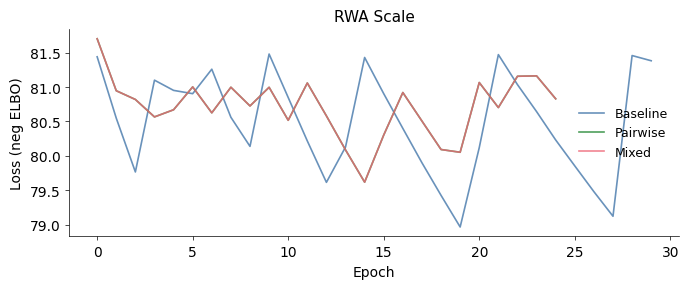

In [16]:
fig = plot_loss_comparison(losses_baseline, losses_imputed, title='RWA Scale',
                          losses_pairwise=losses_pairwise)
fig.savefig('loss_comparison.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 6. Posterior Parameter Estimates

In [17]:
calibrate_manually(model_pairwise, n_samples=32, seed=103)
calibrate_manually(model_imputed, n_samples=32, seed=102)

## 7. Ignorability Analysis

Compute per-item adaptive thresholds comparing pairwise imputation ELPD
against baseline IRT ELPD. Items whose missing values are **ignorable**
do not benefit from imputation over the baseline's own marginalization.

In [18]:
model_imputed.compute_adaptive_thresholds(
    data_factory, baseline_model=model_baseline, sample_size=32
)

import pandas as pd
ignorability_df = pd.DataFrame([
    {
        'Item': item,
        'w_pairwise': f"{mixed_imputation.get_item_weight(item):.4f}",
        'Threshold': f"{model_imputed._adaptive_thresholds[item]:.4f}",
        'Missing Ignorable': model_imputed._ignorable_items[item],
    }
    for item in item_keys
])
n_ignorable = sum(model_imputed._ignorable_items[k] for k in item_keys)
print(f"Ignorability: {n_ignorable}/{len(item_keys)} items have ignorable missing values\n")
print(ignorability_df.to_string(index=False))

model_imputed.save_to_disk('grm_imputed')

Ignorability: 0/22 items have ignorable missing values

Item w_pairwise Threshold  Missing Ignorable
  Q1     1.0000    0.0010              False
  Q2     1.0000    0.0010              False
  Q3     1.0000    0.0010              False
  Q4     1.0000    0.0010              False
  Q5     1.0000    0.0010              False
  Q6     1.0000    0.0010              False
  Q7     1.0000    0.0010              False
  Q8     1.0000    0.0010              False
  Q9     1.0000    0.0010              False
 Q10     1.0000    0.0010              False
 Q11     1.0000    0.0010              False
 Q12     1.0000    0.0010              False
 Q13     1.0000    0.0010              False
 Q14     1.0000    0.0010              False
 Q15     1.0000    0.0010              False
 Q16     1.0000    0.0010              False
 Q17     1.0000    0.0010              False
 Q18     1.0000    0.0010              False
 Q19     1.0000    0.0010              False
 Q20     1.0000    0.0010              False

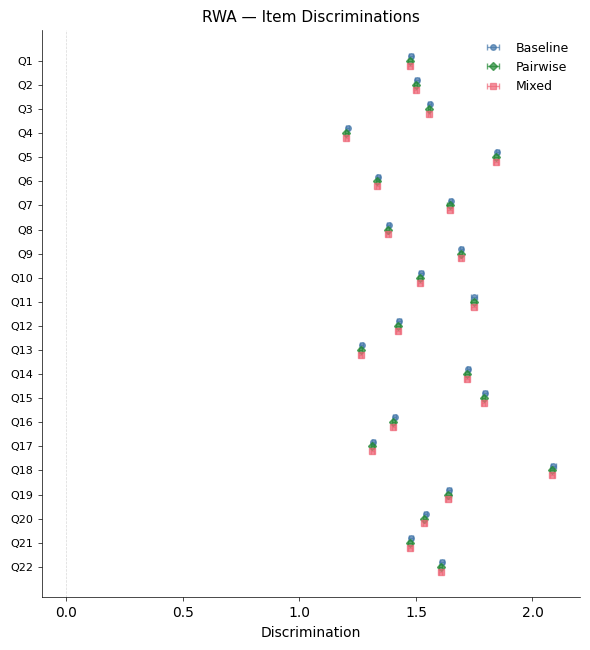

In [19]:
fig = plot_forest_discriminations(item_keys, model_baseline, model_imputed, title='RWA — Item Discriminations',
                                   model_pairwise=model_pairwise)
fig.savefig('discriminations.pdf', bbox_inches='tight', dpi=150)
plt.show()

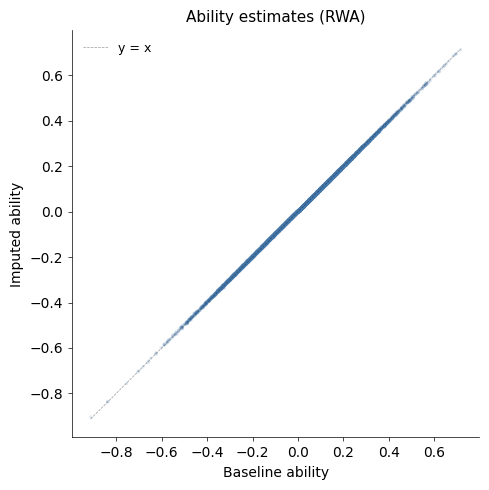

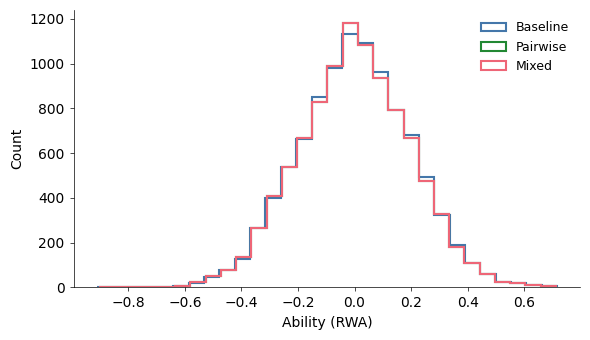

In [20]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_pw = np.array(model_pairwise.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig = plot_ability_scatter(ab_base, ab_imp, label='RWA')
fig.savefig('ability_scatter.pdf', bbox_inches='tight', dpi=150)
plt.show()

fig = plot_ability_distributions(ab_base, ab_imp, label='RWA',
                                  abilities_pairwise=ab_pw)
fig.savefig('ability_distributions.pdf', bbox_inches='tight', dpi=150)
plt.show()

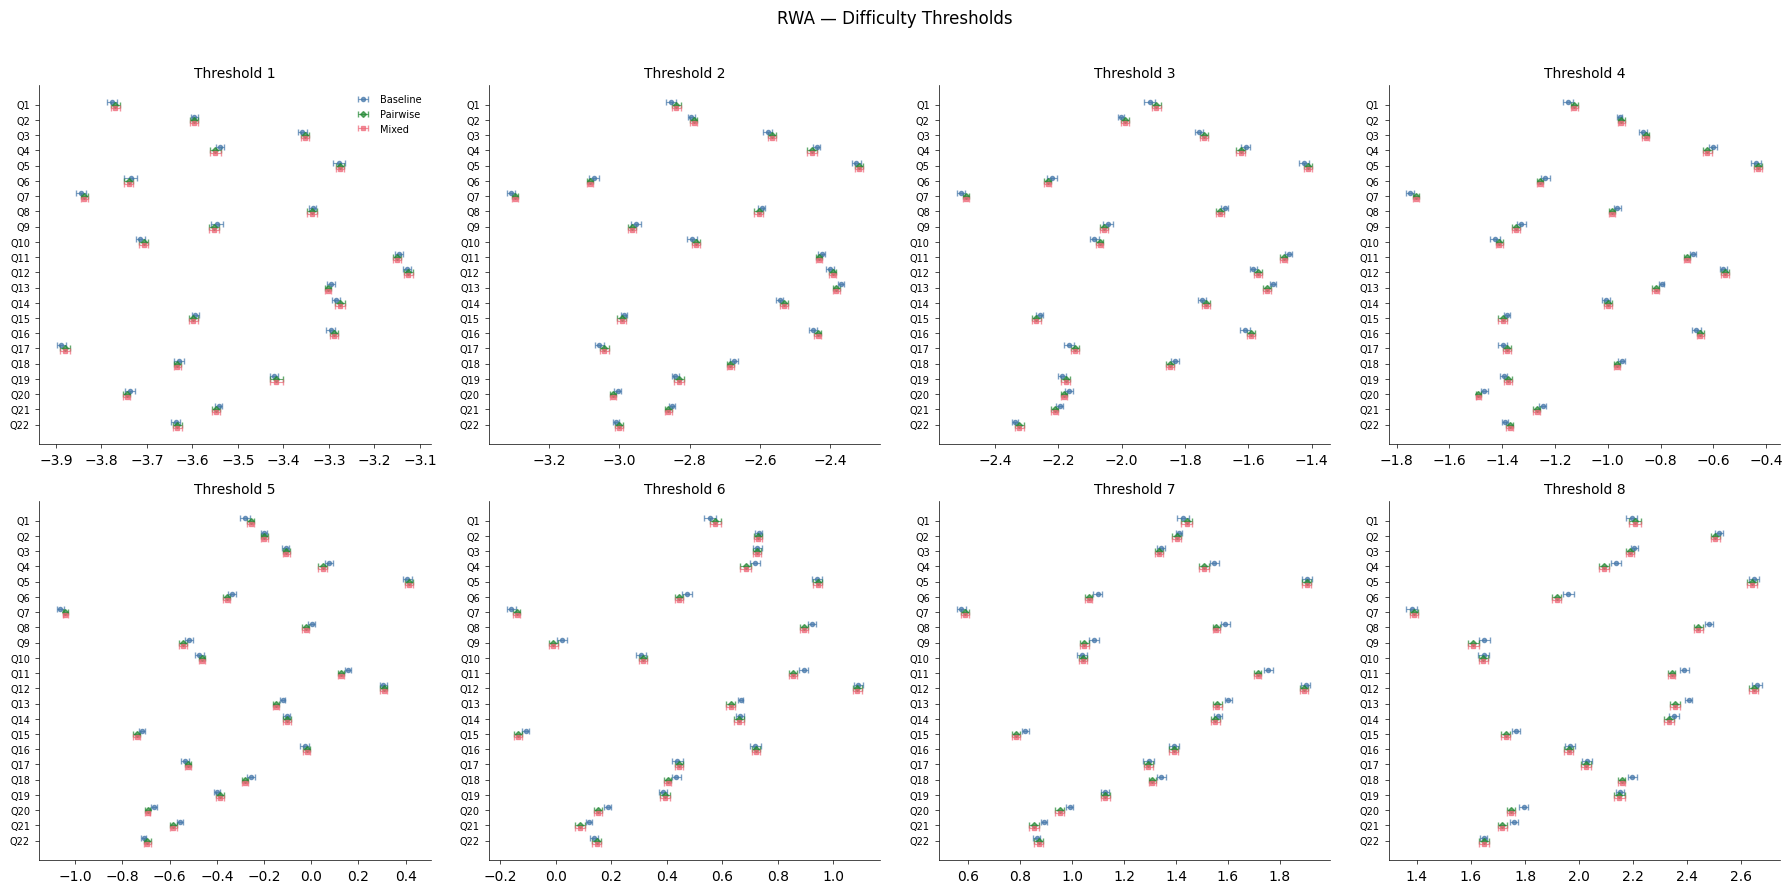

In [21]:
fig = plot_thresholds(item_keys, model_baseline, model_imputed, title='RWA — Difficulty Thresholds',
                       model_pairwise=model_pairwise)
fig.savefig('thresholds.pdf', bbox_inches='tight', dpi=150)
plt.show()

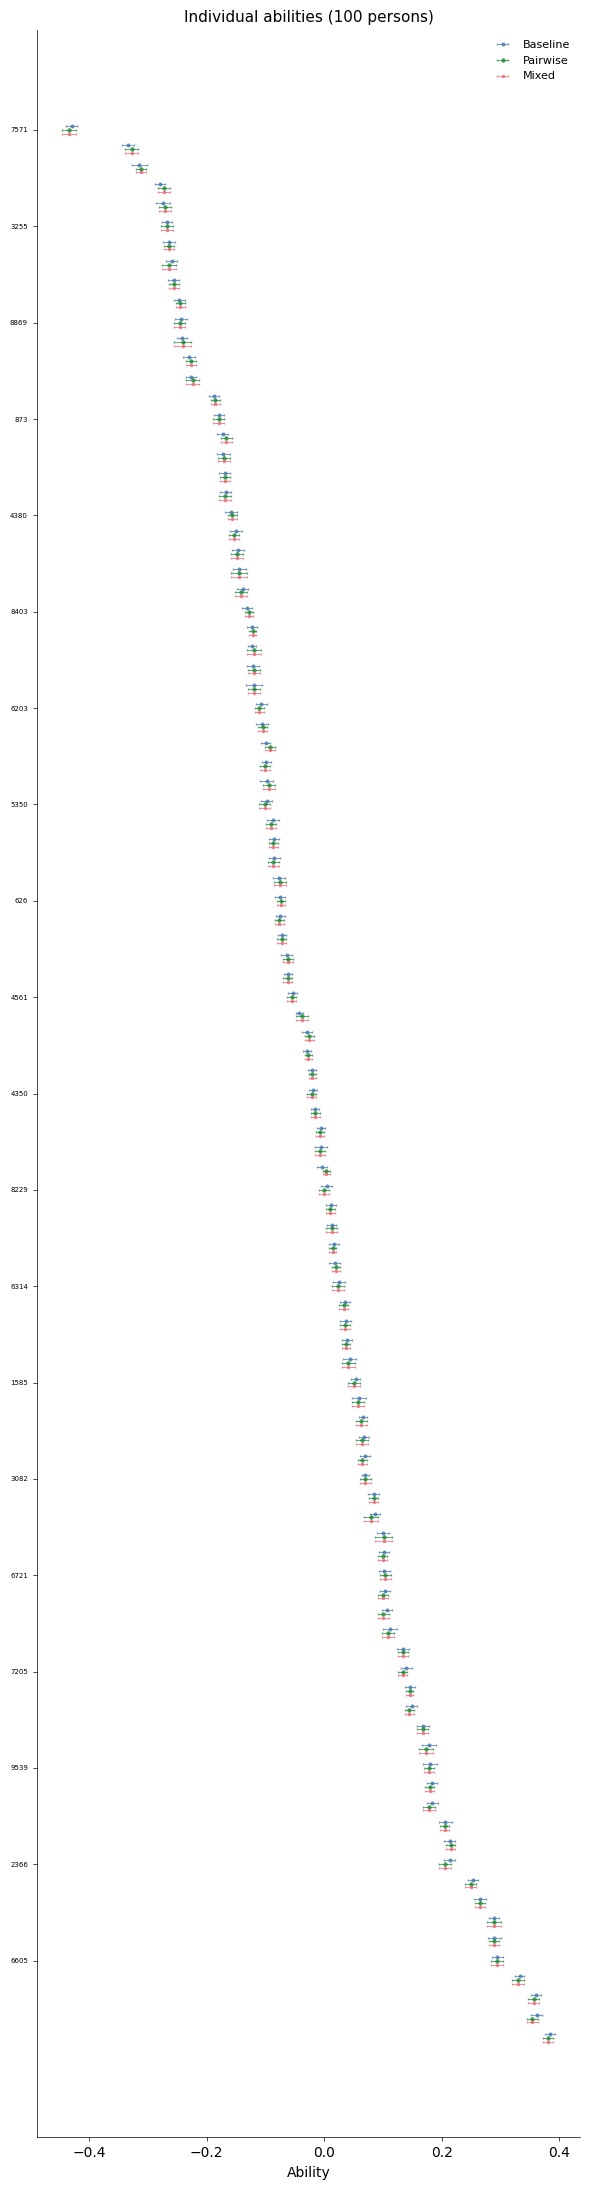

In [22]:
fig = plot_individual_abilities(item_keys, model_baseline, model_imputed,
                                model_pairwise=model_pairwise)
fig.savefig('individual_abilities.pdf', bbox_inches='tight', dpi=150)
plt.show()

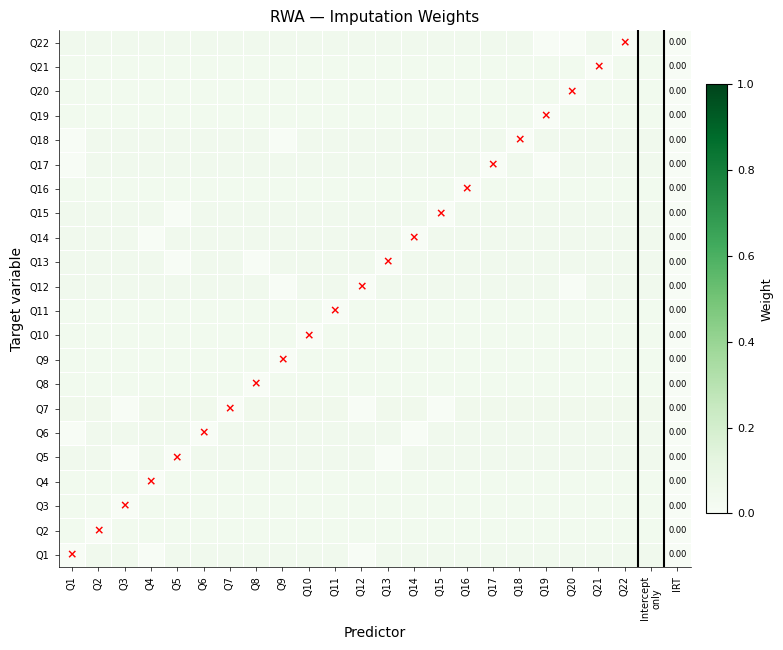

In [23]:
fig = plot_imputation_weights_pcolormesh(pairwise_model, mixed_imputation, item_keys,
                                          title='RWA — Imputation Weights')
fig.savefig('imputation_weights.pdf', bbox_inches='tight', dpi=150)
plt.show()

## 8. Model Comparison Table

In [24]:
import pandas as pd
from scipy.stats import spearmanr

def compute_predictive_metrics(model, data_factory, item_keys, response_cardinality):
    K = response_cardinality
    all_ll, all_se, all_nr = [], [], []
    all_pred, all_obs = [], []
    for batch_data in data_factory():
        pred = model.predictive_distribution(batch_data, **model.surrogate_sample)
        probs = np.array(pred['rv'].probs_parameter())
        S, N_batch, I, _ = probs.shape
        for n in range(N_batch):
            ll, se, nr = 0.0, 0.0, 0
            for i, key in enumerate(item_keys):
                y = batch_data[key][n]
                if np.isnan(y) or y < 0 or y >= K: continue
                y_int = int(y)
                p_mean = probs[:, n, i, :].mean(0)
                ll += np.log(np.maximum(probs[:, n, i, y_int].mean(), 1e-30))
                expected = np.sum(p_mean * np.arange(K))
                se += (expected - y_int) ** 2
                all_pred.append(expected)
                all_obs.append(y_int)
                nr += 1
            if nr > 0: all_ll.append(ll); all_se.append(se); all_nr.append(nr)
    ll, se, nr = np.array(all_ll), np.array(all_se), np.array(all_nr)
    N, total = len(ll), nr.sum()
    rho, _ = spearmanr(all_obs, all_pred)
    return {
        'RMSE': (np.sqrt(se.sum()/total), np.std(np.sqrt(se/nr))/np.sqrt(N)),
        'ELPD/n': (ll.mean(), np.std(ll)/np.sqrt(N)),
        'ELPD/resp': (ll.sum()/total, np.std(ll/nr)/np.sqrt(N)),
        'Spearman': (rho, 0.0),
    }

m_b = compute_predictive_metrics(model_baseline, data_factory, item_keys, response_cardinality)
m_p = compute_predictive_metrics(model_pairwise, data_factory, item_keys, response_cardinality)
m_m = compute_predictive_metrics(model_imputed, data_factory, item_keys, response_cardinality)

rows = []
for metric in ['RMSE', 'ELPD/n', 'ELPD/resp', 'Spearman']:
    b_val, b_se = m_b[metric]
    p_val, p_se = m_p[metric]
    m_val, m_se = m_m[metric]
    if metric == 'Spearman':
        rows.append({
            'Metric': metric,
            'Baseline': f"{b_val:.4f}",
            'Pairwise': f"{p_val:.4f}",
            'Mixed': f"{m_val:.4f}",
        })
    else:
        rows.append({
            'Metric': metric,
            'Baseline': f"{b_val:.3f} ({b_se:.3f})",
            'Pairwise': f"{p_val:.3f} ({p_se:.3f})",
            'Mixed': f"{m_val:.3f} ({m_se:.3f})",
        })
print("RWA — Predictive Performance Comparison\n")
print(pd.DataFrame(rows).to_string(index=False))


RWA — Predictive Performance Comparison

   Metric        Baseline        Pairwise           Mixed
     RMSE   3.379 (0.007)   3.368 (0.007)   3.368 (0.007)
   ELPD/n -77.728 (0.150) -77.075 (0.148) -77.075 (0.148)
ELPD/resp  -3.538 (0.007)  -3.508 (0.007)  -3.508 (0.007)


## Summary

This notebook demonstrated three approaches to fitting a single-scale Graded
Response Model to all 22 RWA items using `GRModel` with `dim=1`:

1. **Baseline (ignorable missingness)** — missing responses are effectively
   skipped by zeroing out their log-likelihood contribution.

2. **Pairwise (PairwiseOrdinalStackingModel)** — a pairwise ordinal stacking
   ensemble imputes missing responses. The GRM analytically marginalizes over
   the imputation distribution (Rao-Blackwellization).

3. **Mixed imputation (pairwise + baseline IRT)** — the pairwise stacking model
   is blended with the baseline IRT model's marginalized predictions via
   per-item softmax weights over ELPD scores:
   `PMF = w_pairwise * pairwise + (1 - w_pairwise) * IRT_baseline`. The GRM
   then analytically marginalizes over the blended imputation distribution
   (Rao-Blackwellization), yielding zero-variance contributions for
   missing cells.

The side-by-side discrimination, ability, and comparison-table plots above
allow direct comparison of the three strategies. When missingness is
informative (non-ignorable), the imputed models are expected to produce
less biased parameter estimates.